<a href="https://colab.research.google.com/github/miriampaul/ML-Classification-Model/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd

In [50]:
loan_df=pd.read_csv('/content/Loan_Default.csv')

In [51]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [52]:
(loan_df[['Credit_Score', 'loan_amount']]-loan_df[['Credit_Score', 'loan_amount']].mean())/loan_df[['Credit_Score', 'loan_amount']].std()

,Credit_Score,loan_amount
0,0.502356,-1.166976
1,-1.275409,-0.677604
2,1.158230,0.409888
3,-0.973362,0.681761
4,-0.843913,1.986752
...,...,...
148665,-0.352007,0.573012
148666,-1.128700,1.388631
148667,0.019080,0.627387
148668,0.321127,-0.731979


In [53]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
std.fit_transform(loan_df[['Credit_Score', 'loan_amount']])

array([[ 0.50235739, -1.16697989],
       [-1.27541323, -0.6776066 ],
       [ 1.15823392,  0.40988958],
       ...,
       [ 0.01907994,  0.62738881],
       [ 0.32112834, -0.73198141],
       [ 1.12371411,  0.40988958]])

In [54]:
import pandas as pd

In [55]:
DM=pd.read_csv('/content/dm (1).csv')

In [56]:
DM.columns

Index(['STUDYID', 'DOMAIN', 'USUBJID', 'SUBJID', 'RFSTDTC', 'RFENDTC',
       'RFXSTDTC', 'RFXENDTC', 'RFICDTC', 'RFPENDTC', 'DTHDTC', 'DTHFL',
       'SITEID', 'AGE', 'AGEU', 'SEX', 'RACE', 'ETHNIC', 'ARMCD', 'ARM',
       'ACTARMCD', 'ACTARM', 'COUNTRY', 'DMDTC', 'DMDY'],
      dtype='object')

In [57]:
DM['ARM']

,ARM
0,Placebo
1,Placebo
2,Xanomeline High Dose
3,Xanomeline Low Dose
4,Xanomeline High Dose
...,...
301,Xanomeline Low Dose
302,Xanomeline High Dose
303,Placebo
304,Xanomeline High Dose


In [58]:
DS=pd.read_csv('/content/ds (1).csv')

In [59]:
SV=pd.read_csv("/content/sv (1).csv")

In [60]:
DS=DS[['USUBJID','DSDECOD','DSCAT','DSSTDTC']]

In [61]:

DS_filtered = DS[
    (~DS['DSDECOD'].isin(['DEATH', 'COMPLETED', 'SCREEN FAILURE', 'SCREENFAILURE', " "])) &
    (DS['DSCAT'].isin(['DISPOSITION EVENT']))
]

In [62]:
DM=DM[['USUBJID','ARM','SITEID']]

In [63]:
DM_filtered = DM[DM['ARM'].str.contains('Placebo', case=False)]

In [64]:
DM_filtered

,USUBJID,ARM,SITEID
0,01-701-1015,Placebo,701
1,01-701-1023,Placebo,701
5,01-701-1047,Placebo,701
10,01-701-1118,Placebo,701
11,01-701-1130,Placebo,701
...,...,...,...
290,01-717-1344,Placebo,717
296,01-718-1139,Placebo,718
297,01-718-1150,Placebo,718
299,01-718-1172,Placebo,718


In [65]:
DS_DM=pd.merge(DM_filtered, DS_filtered, on='USUBJID', how='inner')

In [66]:
#Now let us create an if else condition to flag these subjects before we merge it into a final table containing all subjects
DS_DM['cp_control_arm'] = DS_DM['USUBJID'].apply(lambda x: 'Y' if pd.notna(x) else None)
DS_DM['cp_control_flag'] = DS_DM['USUBJID'].apply(lambda x: 1 if pd.notna(x) else None)

In [67]:
import numpy as np

def add_cp_flags(df):
  df['cp_control_arm'] = np.where(df['USUBJID'].notna(), 'Y', 'N')
  df['cp_control_flag'] = np.where(df['USUBJID'].notna(), 1, 0)
  return df

DS_DM = add_cp_flags(DS_DM)

In [68]:
SV=SV[['USUBJID','VISIT','SVSTDTC']]

In [69]:
SV_filtered = SV[(~SV['VISIT'].isin(['SCREENING 1', 'SCREENING 2', 'AMBUL ECG PLACEMENT', 'AMBUL ECG REMOVAL'])) & (SV['SVSTDTC'].notna())]

In [70]:
DM_SV=pd.merge(DM_filtered, SV_filtered, on='USUBJID',how='left')

In [71]:
#NEXT MERGE WITH DS_DM
FINAL_OUTPUT=pd.merge(DM_SV, DS_DM, on='USUBJID', how='left')

In [72]:
FINAL_OUTPUT.columns

Index(['USUBJID', 'ARM_x', 'SITEID_x', 'VISIT', 'SVSTDTC', 'ARM_y', 'SITEID_y',
       'DSDECOD', 'DSCAT', 'DSSTDTC', 'cp_control_arm', 'cp_control_flag'],
      dtype='object')

In [73]:
FINAL_OUTPUT.drop(["SITEID_y", "ARM_y"], axis=1, inplace=True)

In [74]:
FINAL_OUTPUT['USUBJID'] = FINAL_OUTPUT['USUBJID'].astype(str).str[-4:]

In [75]:
FINAL_OUTPUT['USUBJID']=FINAL_OUTPUT['USUBJID'].astype(int)

In [76]:
import numpy as np
FINAL_OUTPUT['cp_control_arm']=np.where(FINAL_OUTPUT['cp_control_arm']=='Y' , 'Y', 'N')

In [77]:
FINAL_OUTPUT['cp_control_arm']

,cp_control_arm
0,N
1,N
2,N
3,N
4,N
...,...
1033,N
1034,N
1035,N
1036,N


In [78]:


# Convert SVSTDTC to datetime
FINAL_OUTPUT['SVSTDTC'] = pd.to_datetime(FINAL_OUTPUT['SVSTDTC'])

# Compute max date per USUBJID
max_dates = FINAL_OUTPUT.groupby('USUBJID')['SVSTDTC'].transform('max')

# Apply condition: max date AND cp_control_arm == 'Y'
FINAL_OUTPUT['cp_control_flag'] = ((FINAL_OUTPUT['SVSTDTC'] == max_dates) & (FINAL_OUTPUT['cp_control_arm'] == 'Y')).astype(int)


In [85]:
FINAL_OUTPUT[FINAL_OUTPUT['cp_control_flag'] == 1]

,USUBJID,ARM_x,SITEID_x,VISIT,SVSTDTC,DSDECOD,DSCAT,DSSTDTC,cp_control_arm,cp_control_flag
15,1023,Placebo,701,UNSCHEDULED 5.1,2013-02-18,ADVERSE EVENT,DISPOSITION EVENT,2012-09-02,Y,1
16,1023,Placebo,701,AE FOLLOW-UP,2013-02-18,ADVERSE EVENT,DISPOSITION EVENT,2012-09-02,Y,1
17,1023,Placebo,701,RETRIEVAL,2013-02-18,ADVERSE EVENT,DISPOSITION EVENT,2012-09-02,Y,1
22,1047,Placebo,701,RETRIEVAL,2013-07-28,ADVERSE EVENT,DISPOSITION EVENT,2013-03-29,Y,1
106,1345,Placebo,701,WEEK 24,2014-03-18,STUDY TERMINATED BY SPONSOR,DISPOSITION EVENT,2014-03-18,Y,1
124,1387,Placebo,701,RETRIEVAL,2014-08-27,PROTOCOL VIOLATION,DISPOSITION EVENT,2014-03-25,Y,1
189,1096,Placebo,703,WEEK 6,2013-03-29,LOST TO FOLLOW-UP,DISPOSITION EVENT,2013-03-29,Y,1
207,1175,Placebo,703,WEEK 2,2013-12-31,PROTOCOL VIOLATION,DISPOSITION EVENT,2013-12-31,Y,1
208,1175,Placebo,703,AE FOLLOW-UP,2013-12-31,PROTOCOL VIOLATION,DISPOSITION EVENT,2013-12-31,Y,1
249,1010,Placebo,704,WEEK 20,2014-07-09,WITHDRAWAL BY SUBJECT,DISPOSITION EVENT,2014-07-09,Y,1


In [79]:

# Total number of observations
total_obs = FINAL_OUTPUT['SITEID_x'].nunique()

# Count of observations where cp_control_flag == 1
cp_flag_1_count = FINAL_OUTPUT[FINAL_OUTPUT['cp_control_flag'] == 1]['SITEID_x'].count()

# Calculate proportion
proportion = cp_flag_1_count / total_obs
print(proportion)


1.9375


In [ ]:
num_unique_patients = FINAL_OUTPUT['USUBJID'].nunique()
event_rate = 1 / num_unique_patients
print(f"The event rate is: {event_rate}")

In [86]:
event_rate_per_center = FINAL_OUTPUT.groupby('SITEID_x').agg(
    total_cp_events=('cp_control_flag', 'sum'),
    unique_patients=('USUBJID', 'nunique')
)
event_rate_per_center['event_rate'] = event_rate_per_center['total_cp_events'] / event_rate_per_center['unique_patients']
display(event_rate_per_center)

,total_cp_events,unique_patients,event_rate
SITEID_x,,,
701,6,14,0.428571
703,3,6,0.500000
704,4,9,0.444444
705,4,5,0.800000
706,0,1,0.000000
707,0,1,0.000000
708,2,9,0.222222
709,2,7,0.285714
710,4,11,0.363636


In [87]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
event_rate_per_center['ET_ZSCORE']=std.fit_transform(event_rate_per_center[['event_rate']])

In [88]:
event_rate_per_center

,total_cp_events,unique_patients,event_rate,ET_ZSCORE
SITEID_x,,,,
701,6,14,0.428571,0.368916
703,3,6,0.500000,0.606999
704,4,9,0.444444,0.421824
705,4,5,0.800000,1.606949
706,0,1,0.000000,-1.059583
707,0,1,0.000000,-1.059583
708,2,9,0.222222,-0.318880
709,2,7,0.285714,-0.107250
710,4,11,0.363636,0.152477


In [89]:
import numpy as np

event_rate_per_center['Signal_Level'] = np.select(
    [
        event_rate_per_center['ET_ZSCORE'].abs() >= 3,
        event_rate_per_center['ET_ZSCORE'].abs() >= 2,
        event_rate_per_center['ET_ZSCORE'].abs() >= 1.5
    ],
    [
        'Critical',
        'High',
        'Watch'
    ],
    default='Normal'
)

In [90]:
event_rate_per_center

,total_cp_events,unique_patients,event_rate,ET_ZSCORE,Signal_Level
SITEID_x,,,,,
701,6,14,0.428571,0.368916,Normal
703,3,6,0.500000,0.606999,Normal
704,4,9,0.444444,0.421824,Normal
705,4,5,0.800000,1.606949,Watch
706,0,1,0.000000,-1.059583,Normal
707,0,1,0.000000,-1.059583,Normal
708,2,9,0.222222,-0.318880,Normal
709,2,7,0.285714,-0.107250,Normal
710,4,11,0.363636,0.152477,Normal


In [91]:
from scipy.stats import norm

event_rate_per_center['p_value'] = (
    2 * (1 - norm.cdf(abs(event_rate_per_center['ET_ZSCORE'])))
)

In [92]:
event_rate_per_center

,total_cp_events,unique_patients,event_rate,ET_ZSCORE,Signal_Level,p_value
SITEID_x,,,,,,
701,6,14,0.428571,0.368916,Normal,0.712190
703,3,6,0.500000,0.606999,Normal,0.543851
704,4,9,0.444444,0.421824,Normal,0.673154
705,4,5,0.800000,1.606949,Watch,0.108066
706,0,1,0.000000,-1.059583,Normal,0.289334
707,0,1,0.000000,-1.059583,Normal,0.289334
708,2,9,0.222222,-0.318880,Normal,0.749818
709,2,7,0.285714,-0.107250,Normal,0.914591
710,4,11,0.363636,0.152477,Normal,0.878811


In [93]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

std = StandardScaler()

event_rate_per_center['ET_ZSCORE'] = std.fit_transform(
    event_rate_per_center[['event_rate']]
)

event_rate_per_center['p_value'] = (
    2 * (1 - norm.cdf(
        abs(event_rate_per_center['ET_ZSCORE'])
    ))
)

event_rate_per_center['Signal'] = (
    event_rate_per_center['p_value'] < 0.05
)

print(event_rate_per_center)


          total_cp_events  unique_patients  event_rate  ET_ZSCORE  \
SITEID_x                                                            
701                     6               14    0.428571   0.368916   
703                     3                6    0.500000   0.606999   
704                     4                9    0.444444   0.421824   
705                     4                5    0.800000   1.606949   
706                     0                1    0.000000  -1.059583   
707                     0                1    0.000000  -1.059583   
708                     2                9    0.222222  -0.318880   
709                     2                7    0.285714  -0.107250   
710                     4               11    0.363636   0.152477   
711                     0                1    0.000000  -1.059583   
713                     0                3    0.000000  -1.059583   
714                     0                2    0.000000  -1.059583   
715                     2         

In [95]:
overall_et_rate = (
    event_rate_per_center['total_cp_events'].sum()
    / event_rate_per_center['unique_patients'].sum()
)

print(overall_et_rate)

0.36046511627906974


In [97]:
from scipy.stats import binomtest

event_rate_per_center['p_value'] = (
    event_rate_per_center.apply(
        lambda row: binomtest(
            k=row['total_cp_events'],
            n=row['unique_patients'],
            p=overall_et_rate,
            alternative='two-sided'
        ).pvalue,
        axis=1
    )
)

In [100]:
event_rate_per_center['Expected_ET'] = (
    event_rate_per_center['unique_patients']
    * overall_et_rate
)

event_rate_per_center['OE_Ratio'] = (
    event_rate_per_center['total_cp_events']
    / event_rate_per_center['Expected_ET']
)

In [101]:
event_rate_per_center

,total_cp_events,unique_patients,event_rate,ET_ZSCORE,Signal_Level,p_value,Signal,Expected_ET,OE_Ratio
SITEID_x,,,,,,,,,
701,6,14,0.428571,0.368916,Normal,0.588516,False,5.046512,1.188940
703,3,6,0.500000,0.606999,Normal,0.673957,False,2.162791,1.387097
704,4,9,0.444444,0.421824,Normal,0.730813,False,3.244186,1.232975
705,4,5,0.800000,1.606949,Watch,0.060073,False,1.802326,2.219355
706,0,1,0.000000,-1.059583,Normal,1.000000,False,0.360465,0.000000
707,0,1,0.000000,-1.059583,Normal,1.000000,False,0.360465,0.000000
708,2,9,0.222222,-0.318880,Normal,0.503227,False,3.244186,0.616487
709,2,7,0.285714,-0.107250,Normal,1.000000,False,2.523256,0.792627
710,4,11,0.363636,0.152477,Normal,1.000000,False,3.965116,1.008798


In [102]:
display(event_rate_per_center.sort_values(by='OE_Ratio', ascending=False))

,total_cp_events,unique_patients,event_rate,ET_ZSCORE,Signal_Level,p_value,Signal,Expected_ET,OE_Ratio
SITEID_x,,,,,,,,,
717,2,2,1.000000,2.273582,High,0.129935,True,0.720930,2.774194
705,4,5,0.800000,1.606949,Watch,0.060073,False,1.802326,2.219355
715,2,3,0.666667,1.162527,Normal,0.296131,False,1.081395,1.849462
703,3,6,0.500000,0.606999,Normal,0.673957,False,2.162791,1.387097
704,4,9,0.444444,0.421824,Normal,0.730813,False,3.244186,1.232975
701,6,14,0.428571,0.368916,Normal,0.588516,False,5.046512,1.188940
710,4,11,0.363636,0.152477,Normal,1.000000,False,3.965116,1.008798
709,2,7,0.285714,-0.107250,Normal,1.000000,False,2.523256,0.792627
718,1,4,0.250000,-0.226292,Normal,1.000000,False,1.441860,0.693548


<Axes: xlabel='SITEID_x', ylabel='Count'>

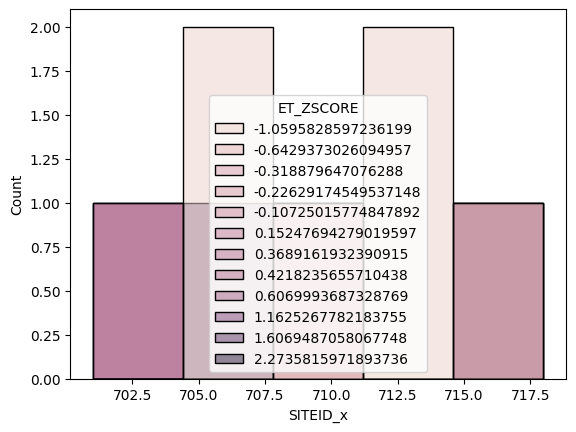

In [104]:
import seaborn as sns
sns.histplot(event_rate_per_center,
             hue='ET_ZSCORE',
             x='SITEID_x')

In [106]:
display(event_rate_per_center[event_rate_per_center['Signal']])

,total_cp_events,unique_patients,event_rate,ET_ZSCORE,Signal_Level,p_value,Signal,Expected_ET,OE_Ratio
SITEID_x,,,,,,,,,
717,2,2,1.0,2.273582,High,0.129935,True,0.72093,2.774194
